In [1]:
import matplotlib.pyplot as plt
import pandas as pd

import scarf
import scarf.plotting as splt

scarf.configure_output(level='WARNING', progress=True)

In [2]:
dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    name='bastidas-ponce_4K_pancreas-d15_rnaseq',
    destination='scarf_datasets',
    zarr=True,
)

Downloading bucket files: 43423201 / 43423201 complete

Downloading bytes: 43423201 / 43423201 complete

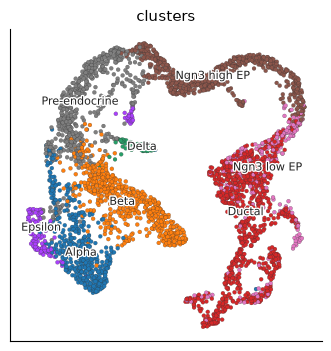

In [3]:
ds = scarf.DataStore(
    f'{dataset}/data.zarr',
    nthreads=4,
    default_assay='RNA',
)
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='clusters',
    legend_loc='on_data',
)

In [4]:
progenitors = ['Ductal']
terminal_cell_types = ['Alpha', 'Beta', 'Delta']

ds.cells.to_pandas_dataframe(
    ['clusters'],
    key='I'
)['clusters'].value_counts()

clusters
Ductal           916
Ngn3 high EP     642
Pre-endocrine    592
Beta             591
Alpha            481
Ngn3 low EP      262
Epsilon          142
Delta             70
Name: count, dtype: int64

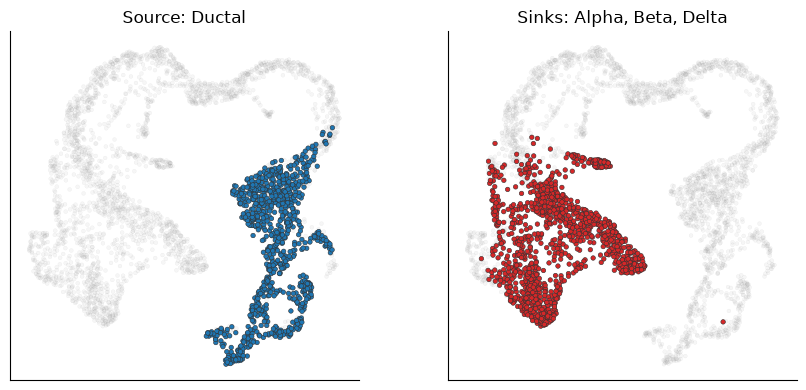

In [5]:
figure, axes = plt.subplots(1, 2, figsize=(9, 4))
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by=None,
    default_color='#bdbdbd',
    point_alpha=0.4,
    highlight=splt.Highlight(
        by='clusters',
        groups=tuple(progenitors),
        color='#1f77b4',
        dim_alpha=0.12,
        size_multiplier=1.35,
        halo_width=0.4,
    ),
    show_titles=False,
    target=axes[0],
    show=False,
)
axes[0].set_title('Source: Ductal')
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by=None,
    default_color='#bdbdbd',
    point_alpha=0.4,
    highlight=splt.Highlight(
        by='clusters',
        groups=tuple(terminal_cell_types),
        color='#d62728',
        dim_alpha=0.12,
        size_multiplier=1.35,
        halo_width=0.4,
    ),
    show_titles=False,
    target=axes[1],
    show=False,
)
axes[1].set_title('Sinks: Alpha, Beta, Delta')
figure.tight_layout()
figure

In [6]:
pseudotime = ds.run_pseudotime_scoring(
    source_sink_key='clusters',
    sources=progenitors,
    sinks=terminal_cell_types,
    label='fate_pseudotime',
)

selected_cells = int(ds.cells.fetch_all('I').sum())
valid_cells = int(ds.cells.fetch_all(pseudotime.validity_key).sum())
pd.Series(
    {
        'pseudotime_key': pseudotime.pseudotime_key,
        'validity_key': pseudotime.validity_key,
        'valid cells': valid_cells,
        'selected cells': selected_cells,
        'valid fraction': valid_cells / selected_cells,
    }
)

pseudotime_key           RNA_fate_pseudotime
validity_key      RNA_fate_pseudotime__valid
valid cells                             3696
selected cells                          3696
valid fraction                           1.0
dtype: object

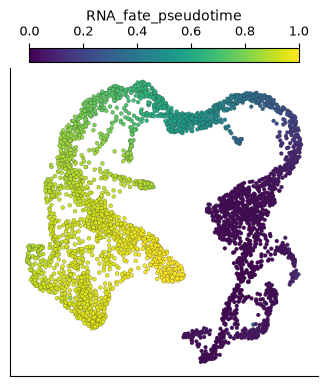

In [7]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by=pseudotime.pseudotime_key,
    subset_by=pseudotime.validity_key,
)

In [8]:
fate = ds.run_fate_mapping(
    cell_key='I',
    subset_cell_key=pseudotime.validity_key,
    pseudotime_key=pseudotime.pseudotime_key,
    sink_key='clusters',
    sinks=terminal_cell_types,
)

fate_valid = int(ds.cells.fetch_all(fate.validity_key).sum())
pd.Series(
    {
        'fate_keys': ', '.join(fate.fate_keys),
        'validity_key': fate.validity_key,
        'valid cells': fate_valid,
        'selected cells': selected_cells,
        'valid fraction': fate_valid / selected_cells,
    }
)

fate_keys         RNA_RNA_fate_pseudotime__valid_fate_Alpha, RNA...
validity_key             RNA_RNA_fate_pseudotime__valid_fate__valid
valid cells                                                    3696
selected cells                                                 3696
valid fraction                                                  1.0
dtype: object

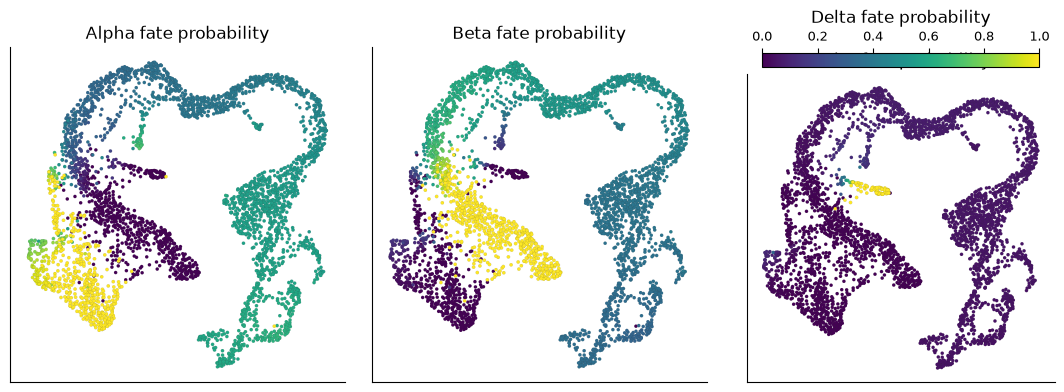

In [9]:
figure, axes = plt.subplots(1, 3, figsize=(11, 4))
probability_scale = splt.ColorScale(vmin=0, vmax=1)
for index, (axis, sink, fate_key) in enumerate(
    zip(axes, fate.sink_labels, fate.fate_keys, strict=True)
):
    ds.plots.embedding(
        layout_key="RNA_UMAP",
        color_by=fate_key,
        subset_by=fate.validity_key,
        color_scale=probability_scale,
        sort_values=True,
        show_legend=index == 2,
        show_titles=False,
        target=axis,
        show=False,
    )
    axis.set_title(f"{sink} fate probability")
for colorbar_axis in set(figure.axes) - set(axes):
    colorbar_axis.set_title(f"{fate.sink_labels[-1]} fate probability")
    colorbar_axis.set_xlabel("")
    colorbar_axis.set_ylabel("")
figure.tight_layout()
figure

In [10]:
fate_frame = ds.cells.to_pandas_dataframe(
    ['clusters', *fate.fate_keys],
    key=fate.validity_key,
)
(
    fate_frame.groupby('clusters', sort=True)[list(fate.fate_keys)]
    .mean()
    .rename(columns=dict(zip(fate.fate_keys, fate.sink_labels, strict=True)))
    .round(3)
)

,Alpha,Beta,Delta
clusters,,,
Alpha,1.000,0.000,0.000
Beta,0.000,1.000,0.000
Delta,0.000,0.000,1.000
Ductal,0.578,0.373,0.049
Epsilon,0.854,0.086,0.059
Ngn3 high EP,0.415,0.517,0.068
Ngn3 low EP,0.557,0.391,0.051
Pre-endocrine,0.357,0.588,0.055
